# The negative control (MLP-View) and a lifter shoot-out 🥊
### Why we need a baseline that *ignores* geometry, and how all the lifters compare

This notebook closes the series. It does two things:

1. **MLP-View (`mlp_view`)**: a "lifter" that learns a fixed mapping from image cells to BEV cells with a plain `Linear` layer and **never looks at the camera calibration**.
   It is the repo's *negative control*: if a fancy lifter can't beat it, the fancy lifter isn't really using geometry.
2. **A shoot-out** of every lifter in the library on the same data, same encoder, same training budget. You will see accuracy, the geometry test, parameter count and speed side by side.

| Step | Question |
|---|---|
| 0 | Setup |
| 1 | What exactly is MLP-View? |
| 2 | Where it works: a camera rig that never moves |
| 3 | Where it breaks: a rig that rotates in every scene |
| 4 | Proof that it ignores the calibration |
| 5 | The shoot-out: all 7 lifters |
| 6 | Which lifter should I use? |

## Step 0: Setup

In [1]:
import math, time, dataclasses
import numpy as np
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt

from lifting import GridSpec, Cameras, build_bev_model
from lifting.data import SceneBatch, SyntheticSceneDataset
from lifting.geometry import DepthBins
from lifting.training import BEVSegmentationTask, Trainer

torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "image.interpolation": "nearest"})
print("torch", torch.__version__)

from lifting import LIFTERS
from lifting.data import CameraRig
from lifting.lifters import MLPViewLifter

torch 2.14.1


In [2]:
grid = GridSpec(resolution=(32, 32, 4))
ext = [grid.x_bounds[0], grid.x_bounds[1], grid.y_bounds[0], grid.y_bounds[1]]

def make_data(yaw_jitter):
    ds = SyntheticSceneDataset(256, grid, rig=CameraRig(yaw_jitter_deg=yaw_jitter), seed=1)
    mk = lambda lo, hi: [SceneBatch.collate([ds[i + j] for j in range(4)]) for i in range(lo, hi, 4)]
    return mk(0, 192), mk(192, 256)

train_rand, test_rand = make_data(180.0)      # the standard benchmark: the rig is rotated randomly in every scene
train_fix,  test_fix  = make_data(0.0)        # an easy variant: the rig always looks the same way

def train_and_eval(name, train, test, steps=250, seed=0, **kw):
    torch.manual_seed(seed)
    model = build_bev_model(name, grid, num_classes=3, image_size=(48, 96), num_cameras=4, channels=32, **kw)
    trainer = Trainer(model, BEVSegmentationTask(3))
    t0 = time.time(); trainer.fit(train, steps=steps); dt = time.time() - t0
    return model, trainer, trainer.evaluate(test).mean_foreground(), dt
print("ready")

ready


### 🖼️ Diagram: the family of lifters
How the seven methods relate. Moving right adds learned machinery.

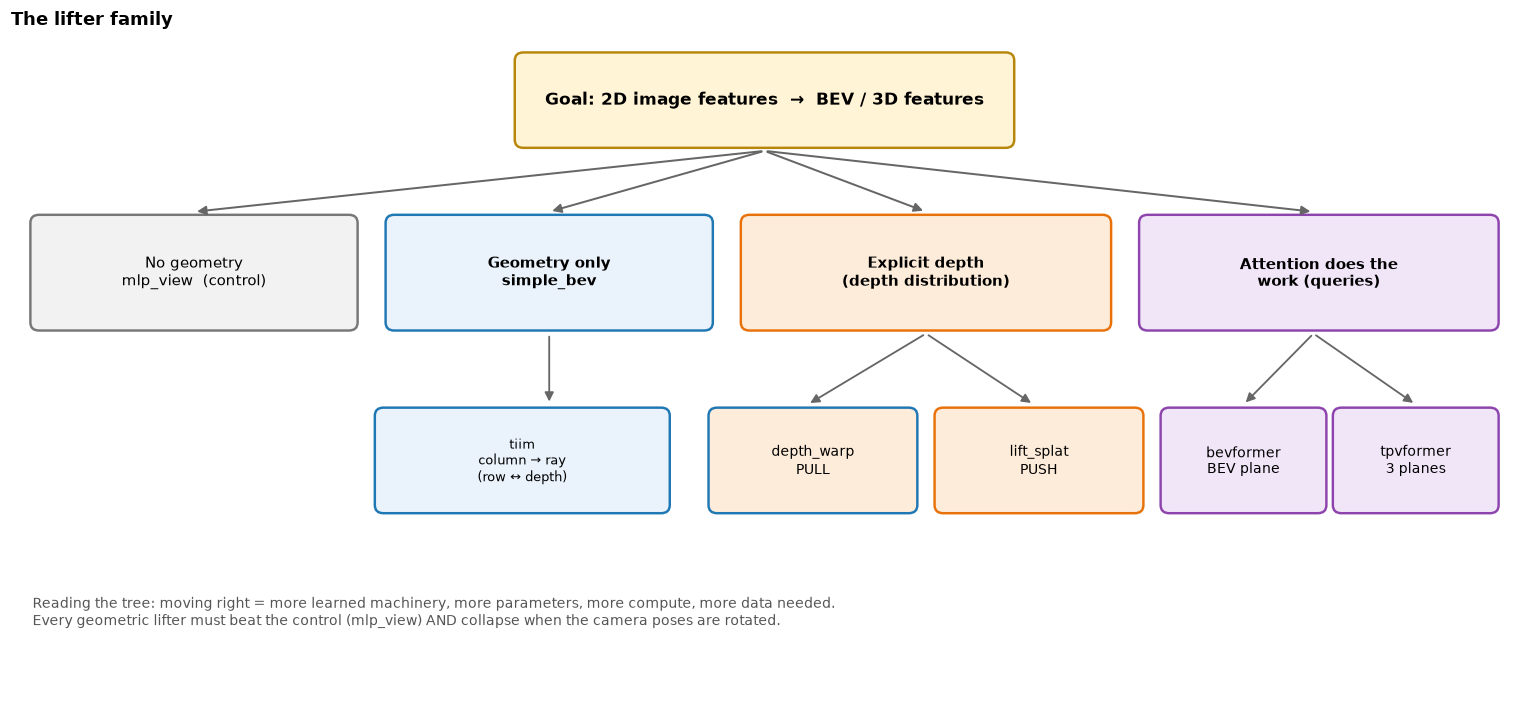

In [3]:
import os, sys
for _p in (".", "notebooks", os.path.join("..", "notebooks")):
    if os.path.exists(os.path.join(_p, "lifting_diagrams.py")):
        sys.path.insert(0, _p); break
import lifting_diagrams as dg
dg.fig_lifter_family()

## Step 1: What exactly is MLP-View?

Take the (coarse) image feature map `(C, h, w)` of each camera and flatten the spatial cells: `h·w` numbers per channel.
A `Linear(h·w → X·Y)` layer then says: *"BEV cell `j` is a weighted sum of all image cells"*. One such `Linear` per camera. That's the
View Parsing Network (VPN) idea (Pan et al., 2020). No projection, no depth, no attention, and **`cameras` is never used**.

### 🖼️ Diagram: why MLP-View cannot follow a moving rig

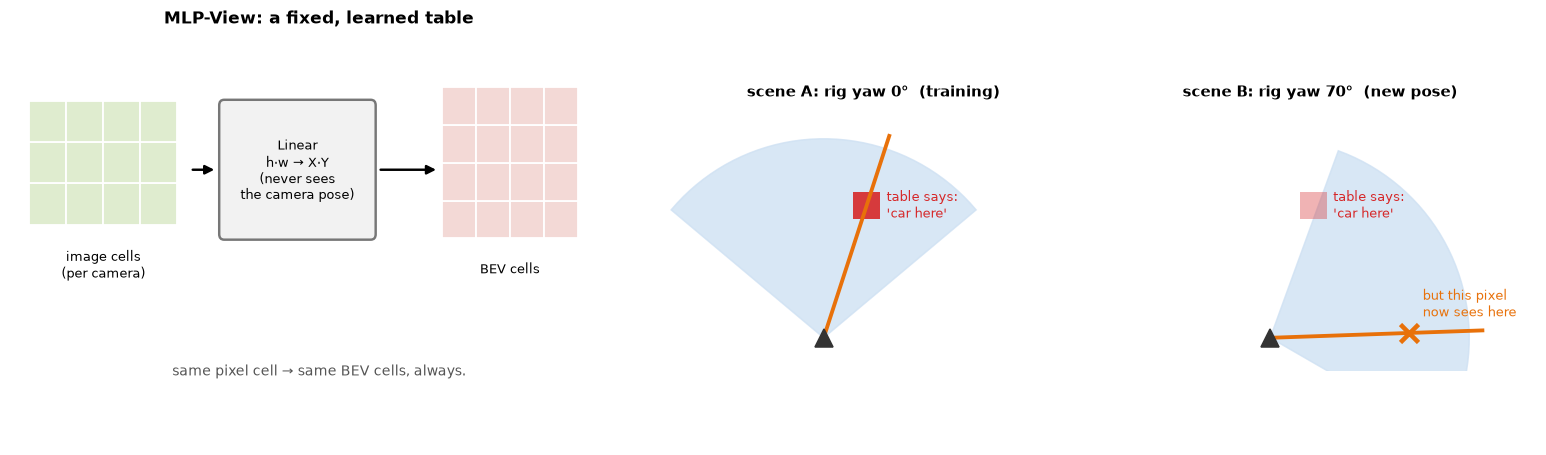

In [4]:
dg.fig_mlp_vs_geometry()

In [5]:
mlp = MLPViewLifter(grid, in_channels=32, out_channels=32, feature_size=(6, 12), num_cameras=4)
print("uses_geometry flag:", mlp.uses_geometry, " (False only for this control)")
lin = mlp.view_mlps[0]
print(f"Linear per camera : {lin.in_features} image cells -> {lin.out_features} BEV cells = {lin.weight.numel():,} weights")
print(f"4 cameras         : {sum(p.numel() for p in mlp.view_mlps.parameters()):,} parameters in the view MLPs alone")
print("forward(features, cameras) never reads `cameras`: look at the source: bev = sum(mlp(flat[:, i]) ...)")

uses_geometry flag: False  (False only for this control)
Linear per camera : 72 image cells -> 1024 BEV cells = 73,728 weights
4 cameras         : 299,008 parameters in the view MLPs alone
forward(features, cameras) never reads `cameras`: look at the source: bev = sum(mlp(flat[:, i]) ...)


## Step 2: Where it works: a camera rig that never moves

If the cameras always sit in the same place, a *fixed* image-cell → BEV-cell table is enough, since the same pixel always sees the same patch of ground.
Train MLP-View and Simple-BEV on the fixed rig (about 30 s):

In [6]:
res_fix = {}
for name in ("mlp_view", "simple_bev"):
    m, t, miou, dt = train_and_eval(name, train_fix, test_fix)
    res_fix[name] = (m, t, miou)
    print(f"{name:11s} fixed rig -> test mIoU {miou:.3f}  ({dt:.0f}s)")

mlp_view    fixed rig -> test mIoU 0.127  (42s)


MLP-View learns *something* (well above chance, which is ~0.02 here) even though it knows nothing about geometry: it memorises "pixel cell → ground cell"
for this one layout. Simple-BEV is still much better, because it uses the actual projection.

Let's look at what MLP-View memorised. Each image cell of camera 0 writes to the BEV cells through one row of the weight matrix. Below: |weights| of a few image cells,
reshaped to the BEV grid.

In [ ]:
mlp_fixed = res_fix["mlp_view"][0].lifter
Wt = mlp_fixed.view_mlps[0].weight.detach()          # (X*Y, h*w) -> column = one image cell
fig, ax = plt.subplots(1, 4, figsize=(14, 3.2))
for a, (r, c) in zip(ax, [(2, 2), (3, 6), (4, 9), (5, 6)]):
    cell = r * 12 + c
    a.imshow(Wt[:, cell].abs().view(32, 32).T, origin="lower", extent=ext, cmap="magma"); a.set_title(f"image cell (row {r}, col {c})\nof camera 0: |weight| per BEV cell")
    a.set_xlabel("x (m)")
ax[0].set_ylabel("y (m)")
plt.tight_layout(); plt.show()

Honestly, these maps look like **noise**: with 192 scenes and 250 steps the table has not discovered a clean ray pattern. It scores above chance only through weak, global correlations (it learns roughly where objects tend to be). A projection-based lifter gets the exact ray pattern *for free* from `cameras.project`.

## Step 3: Where it breaks: a rig that rotates in every scene

In the benchmark data the whole rig is rotated by a random yaw in every scene, so "the same pixel sees the same ground" is false.
The only way to know where the cameras point is the **calibration**.

In [ ]:
res_rand = {}
for name in ("mlp_view", "simple_bev"):
    m, t, miou, dt = train_and_eval(name, train_rand, test_rand)
    res_rand[name] = (m, t, miou)
    print(f"{name:11s} random rig -> test mIoU {miou:.3f}  ({dt:.0f}s)")

MLP-View collapses to ≈ 0 (it can only predict "empty"), while Simple-BEV is unaffected. That gap is the whole point of the control: **a method that beats it must be using the calibration.**

## Step 4: Proof that it ignores the calibration

Two models trained on the **fixed** rig. Now evaluate them with the extrinsics rotated by 90° (images and labels unchanged).
A geometric lifter should break; MLP-View, which never reads the cameras, must give *exactly* the same answer.

In [ ]:
Rz = torch.eye(4); Rz[0, 0], Rz[0, 1], Rz[1, 0], Rz[1, 1] = 0.0, -1.0, 1.0, 0.0
rotate_rig = lambda b: dataclasses.replace(b, cameras=b.cameras.transformed(Rz))
print(f"{'lifter':11s} {'normal':>8s} {'rotated extrinsics':>20s}")
for name in ("mlp_view", "simple_bev"):
    t = res_fix[name][1]
    print(f"{name:11s} {t.evaluate(test_fix).mean_foreground():8.3f} {t.evaluate(test_fix, transform=rotate_rig).mean_foreground():20.3f}")

This is exactly what `lifting-verify` automates: each lifter must (1) beat MLP-View by ≥ 0.15 mIoU on the random-rig data, (2) lose ≥ 50% of its score when the extrinsics are rotated, and (3) reduce its loss by ≥ 30%.

## Step 5: The shoot-out 🥊

Every lifter, same encoder (`SimpleConvEncoder`, 32 channels), same decoder and head, same data (random rig), same 250 steps of training, same seed.
This takes about 2 minutes on a CPU. (Single-seed numbers on a tiny dataset are noisy: differences of ±0.05 mIoU are not meaningful.)

In [ ]:
names = ["mlp_view", "simple_bev", "depth_warp", "lift_splat", "tiim", "bevformer", "tpvformer"]
board = {}
for name in names:
    m, t, miou, dt = train_and_eval(name, train_rand, test_rand)
    rot = t.evaluate(test_rand, transform=rotate_rig).mean_foreground()
    board[name] = dict(model=m, trainer=t, miou=miou, rot=rot, sec=dt,
                       params=sum(p.numel() for p in m.lifter.parameters()), loss0=t.history.smoothed(15)[0], loss1=t.history.smoothed(15)[-1])
    print(f"{name:11s} mIoU {miou:.3f}  rotated {rot:.3f}  {dt:4.0f}s")

In [ ]:
base = board["mlp_view"]["miou"]
print(f"{'lifter':11s} {'mIoU':>6s} {'rotated':>8s} {'params':>9s} {'time':>6s} {'loss':>13s}  beats MLP-View by 0.15 | drops >=50% when rotated")
for n, r in board.items():
    beats = "yes" if r["miou"] - base >= 0.15 else "no "
    drops = "yes" if r["rot"] <= 0.5 * r["miou"] else "no "
    print(f"{n:11s} {r['miou']:6.3f} {r['rot']:8.3f} {r['params']:9,d} {r['sec']:5.0f}s {r['loss0']:5.2f}->{r['loss1']:4.2f}  {beats:^26s}| {drops}")
print("\n(mlp_view is the control itself, so 'beats MLP-View' is expected to be 'no' for it.)")

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
x = np.arange(len(names)); wd = 0.38
ax[0].bar(x - wd/2, [board[n]["miou"] for n in names], wd, label="correct extrinsics")
ax[0].bar(x + wd/2, [board[n]["rot"] for n in names], wd, label="rotated 90°")
ax[0].set_xticks(x); ax[0].set_xticklabels(names, rotation=30); ax[0].set_ylabel("mIoU"); ax[0].legend(); ax[0].set_title("accuracy and the geometry test")
ax[1].bar(names, [board[n]["params"] for n in names], color="tab:green"); ax[1].set_title("lifter parameters"); ax[1].tick_params(axis="x", rotation=30)
ax[2].bar(names, [board[n]["sec"] for n in names], color="tab:orange"); ax[2].set_title("training time for 250 steps (s, CPU)"); ax[2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### Qualitative comparison on unseen scenes
Rows: ground truth and each lifter's prediction (top view).

In [ ]:
tb = test_rand[0]
fig, ax = plt.subplots(len(names) + 1, 4, figsize=(8.5, 2.1 * (len(names) + 1)))
for s in range(4):
    ax[0, s].imshow(tb.bev_labels[s].T, origin="lower", vmin=0, vmax=2); ax[0, s].set_title(f"scene {s}")
ax[0, 0].set_ylabel("ground truth")
for r, n in enumerate(names, start=1):
    pred = board[n]["trainer"].predict(tb)
    for s in range(4):
        ax[r, s].imshow(pred[s].T, origin="lower", vmin=0, vmax=2)
    ax[r, 0].set_ylabel(n, fontsize=9)
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### 🖼️ Diagram: a quick decision flow (details in the table below)

In [ ]:
dg.fig_decision_flow()

## Step 6: Which lifter should I use?

| lifter | how it lifts | direction | learned parameters in the lift | depth handling | strengths | weaknesses |
|---|---|---|---|---|---|---|
| `simple_bev` | project voxel → bilinear read → mean | pull | none (only height compressor) | none (smears along the ray) | simplest, fast, strong baseline | no depth reasoning, no occlusion |
| `depth_warp` | depth distribution × context → frustum, voxels trilinearly read it | pull | depth head | explicit distribution | no holes, depth-aware | big frustum tensor |
| `lift_splat` | frustum points splatted (summed) into voxels | push | depth head | explicit distribution | the classic, accumulates evidence | holes far away, big memory |
| `tiim` | column transformer → polar ray → resample | pull | transformer | implicit via row↔depth | cheap attention, learns ground geometry | per-column isolation, flat-ground bias |
| `bevformer` | BEV queries + deformable attention into pillar reference points | pull (attention) | queries + attention | none explicit; attention picks pixels | flexible, scales, multi-scale | slower, data hungry |
| `tpvformer` | three planes of queries, hybrid + image attention | pull (attention) | queries + attention | none explicit | keeps height, 3D occupancy and point queries | most complex |
| `mlp_view` | learned fixed table | none | big linear layers | none | shows nothing but a *control* | ignores geometry, breaks on new poses |

**Rules of thumb for a beginner**
* Start with **`simple_bev`**: if it works, you're done.
* Need sharper object shapes / depth-awareness → **`depth_warp`** or **`lift_splat`**.
* Many cameras, long range, enough data → **`bevformer`**.
* Need the full 3D occupancy or arbitrary 3D point queries → **`tpvformer`**.
* Always compare against **`mlp_view`** to be sure the calibration is actually used.

### 🧪 Exercises
1. Re-run Step 5 with `seed=1` and `seed=2`. Which rankings are stable and which are noise?
2. Train 3× longer (`steps=750`). Do attention-based lifters (`bevformer`, `tpvformer`) catch up with `simple_bev`?
3. Use `GridSpec(resolution=(48, 48, 4))`. Which lifter's time grows the most?
4. Add your own lifter: see `examples/custom_lifter.py` and compare it to these in the table.
5. Read the other notebooks in this folder for a deep dive on each lifter.